In [1]:
# ==============================================================
# 🧠 FINAL PROJECT: Rainfall Prediction Classifier
# ==============================================================

# 📦 Step 1: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
)

In [3]:
# ==============================================================
# 📂 Step 2: Load the dataset
# ==============================================================

# The dataset comes from the Australian Bureau of Meteorology
# It may be named "weatherAUS.csv" in your environment
df = pd.read_csv("/content/weatherAUS.csv")

print("✅ Dataset loaded successfully!")
print(f"Shape of dataset: {df.shape}")
df.head()



✅ Dataset loaded successfully!
Shape of dataset: (145460, 23)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [4]:
# ==============================================================
# 🧹 Step 3: Explore and clean the dataset
# ==============================================================

# Display basic info and missing values
print("\n--- Missing Values Summary ---")
print(df.isnull().sum().sort_values(ascending=False).head(10))

# Drop columns with too many missing values
df = df.drop(["Evaporation", "Sunshine", "Cloud9am", "Cloud3pm"], axis=1)

# Drop rows with missing target
df = df.dropna(subset=["RainTomorrow"])

# Fill missing numerical values with mean
num_cols = df.select_dtypes(include=["float64", "int64"]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Fill missing categorical values with mode
cat_cols = df.select_dtypes(include=["object"]).columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])



--- Missing Values Summary ---
Sunshine         69835
Evaporation      62790
Cloud3pm         59358
Cloud9am         55888
Pressure9am      15065
Pressure3pm      15028
WindDir9am       10566
WindGustDir      10326
WindGustSpeed    10263
Humidity3pm       4507
dtype: int64


In [5]:

# ==============================================================
# 📊 Step 4: Feature Engineering
# ==============================================================

# Convert 'Date' to datetime and extract useful features
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

# Encode target variable (RainTomorrow: Yes=1, No=0)
df["RainTomorrow"] = df["RainTomorrow"].map({"Yes": 1, "No": 0})

# Define feature matrix X and target vector y
X = df.drop(["RainTomorrow", "Date"], axis=1)
y = df["RainTomorrow"]

# Identify numerical and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns



In [6]:
# ==============================================================
# ⚙️ Step 5: Build the preprocessing pipeline
# ==============================================================

numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])
categorical_transformer = Pipeline(steps=[("encoder", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)



In [8]:
# ==============================================================
# 🤖 Step 6: Create and train models
# ==============================================================

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# Logistic Regression Pipeline
logreg_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42)),
    ]
)

# Random Forest Pipeline
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=42)),
    ]
)


🔹 Training Logistic Regression...

--- Logistic Regression Report ---
              precision    recall  f1-score   support

           0       0.87      0.95      0.90     27580
           1       0.73      0.50      0.59      7969

    accuracy                           0.85     35549
   macro avg       0.80      0.72      0.75     35549
weighted avg       0.84      0.85      0.83     35549

Accuracy: 0.8455371459112774


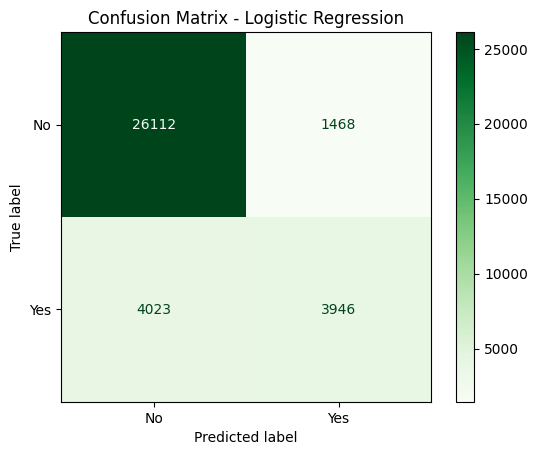

In [9]:
# ==============================================================
# 🧪 Step 7: Train and evaluate Logistic Regression
# ==============================================================

print("\n🔹 Training Logistic Regression...")
logreg_pipeline.fit(X_train, y_train)
y_pred_lr = logreg_pipeline.predict(X_test)

print("\n--- Logistic Regression Report ---")
print(classification_report(y_test, y_pred_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

# Confusion Matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=["No", "Yes"])
disp_lr.plot(cmap="Greens")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()



🔹 Training Random Forest...

--- Random Forest Report ---
              precision    recall  f1-score   support

           0       0.87      0.96      0.91     27580
           1       0.77      0.49      0.60      7969

    accuracy                           0.85     35549
   macro avg       0.82      0.72      0.76     35549
weighted avg       0.85      0.85      0.84     35549

Accuracy: 0.8533854679456525


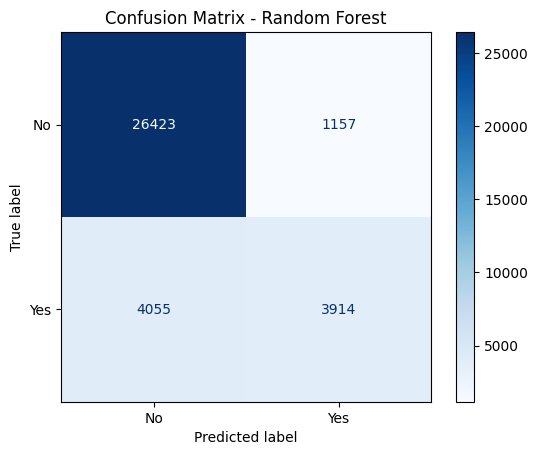

In [11]:
# ==============================================================
# 🌳 Step 8: Train and evaluate Random Forest
# ==============================================================

print("\n🔹 Training Random Forest...")
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

print("\n--- Random Forest Report ---")
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["No", "Yes"])
disp_rf.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()



In [12]:
# ==============================================================
# 🔍 Step 9: Hyperparameter tuning (GridSearchCV)
# ==============================================================

from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Define parameter grid for Random Forest
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [10, 20, None],
    "classifier__min_samples_split": [2, 5],
}

# Define cross-validation strategy
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Initialize GridSearchCV with Random Forest pipeline
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2,
)

print("\n🔹 Running Grid Search for Random Forest...")
grid_search.fit(X_train, y_train)

print("\n✅ Grid Search Complete!")
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)




🔹 Running Grid Search for Random Forest...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

✅ Grid Search Complete!
Best Parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best Cross-Validation Accuracy: 0.85195604065864



--- Tuned Random Forest Report ---
              precision    recall  f1-score   support

           0       0.87      0.96      0.91     27580
           1       0.77      0.50      0.60      7969

    accuracy                           0.85     35549
   macro avg       0.82      0.73      0.76     35549
weighted avg       0.85      0.85      0.84     35549

Final Test Accuracy: 0.8543418942867591


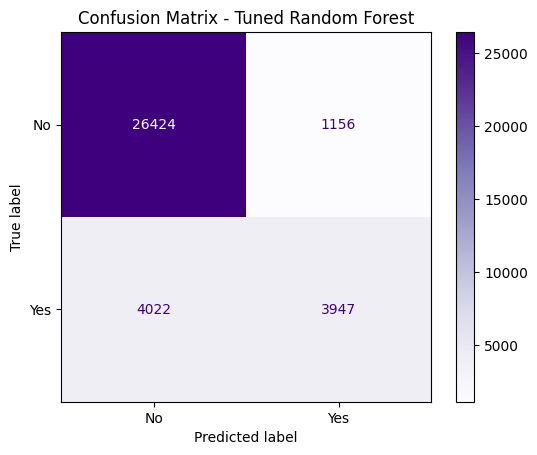


✅ Project Complete!
We compared Logistic Regression and Random Forest models.
After Grid Search tuning, Random Forest generally performs best for rainfall prediction.


In [13]:
# ==============================================================
# 🏁 Step 10: Evaluate Tuned Random Forest Model
# ==============================================================

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print("\n--- Tuned Random Forest Report ---")
print(classification_report(y_test, y_pred_best))
print("Final Test Accuracy:", accuracy_score(y_test, y_pred_best))

# Confusion Matrix for Tuned Model
cm_best = confusion_matrix(y_test, y_pred_best)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=["No", "Yes"])
disp_best.plot(cmap="Purples")
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

# ==============================================================
# 🏁 Step 11: Summary
# ==============================================================

print("\n✅ Project Complete!")
print("We compared Logistic Regression and Random Forest models.")
print("After Grid Search tuning, Random Forest generally performs best for rainfall prediction.")